# ASL Finger Spelling Recognition - Landmark-Based Model Training

## Project Overview
This notebook implements an American Sign Language (ASL) finger spelling recognition system using MediaPipe hand landmarks and sklearn classifiers.

### Approach:
- Extract 21 hand landmarks (x, y coordinates = 42 features)
- Train multiple sklearn classifiers
- Compare performance and select best model

### Contents:
1. Setup & Configuration
2. Exploratory Data Analysis (EDA)
3. Landmark Extraction
4. Model Training & Comparison
5. Evaluation & Classification Report
6. Save Model

## 1. Setup & Configuration

In [11]:
import os
import sys
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from tqdm import tqdm
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# MediaPipe
import mediapipe as mp

# Sklearn
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

print(f"NumPy: {np.__version__}")
print(f"MediaPipe: {mp.__version__}")
print("Setup complete!")

NumPy: 1.26.4
MediaPipe: 0.10.18
Setup complete!


In [12]:
# Configuration
DATASET_DIR = Path('../dataset/asl_alphabet_train/asl_alphabet_train')
MODEL_SAVE_DIR = Path('../models')
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

SAMPLES_PER_CLASS = 300  # Images to process per class
TEST_SIZE = 0.2

# ASL Labels (29 classes)
LABELS = [
    'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M',
    'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
    'del', 'nothing', 'space'
]

NUM_CLASSES = len(LABELS)
FEATURE_DIM = 42  # 21 landmarks x 2 (x, y)

print(f"Dataset Directory: {DATASET_DIR}")
print(f"Number of Classes: {NUM_CLASSES}")
print(f"Feature Dimension: {FEATURE_DIM}")
print(f"Samples per Class: {SAMPLES_PER_CLASS}")

Dataset Directory: ../dataset/asl_alphabet_train/asl_alphabet_train
Number of Classes: 29
Feature Dimension: 42
Samples per Class: 300


## 2. Exploratory Data Analysis (EDA)

In [13]:
# Analyze dataset structure
print("=" * 60)
print("DATASET ANALYSIS")
print("=" * 60)

dataset_stats = []

for label in LABELS:
    label_dir = DATASET_DIR / label
    if label_dir.exists():
        images = list(label_dir.glob("*.jpg")) + list(label_dir.glob("*.png"))
        dataset_stats.append({
            'Label': label,
            'Count': len(images),
            'Type': 'Letter' if label.isalpha() and len(label) == 1 else 'Special'
        })
    else:
        dataset_stats.append({'Label': label, 'Count': 0, 'Type': 'Missing'})

stats_df = pd.DataFrame(dataset_stats)
print(f"\nTotal Images: {stats_df['Count'].sum():,}")
print(f"Classes Found: {(stats_df['Count'] > 0).sum()}/{NUM_CLASSES}")
print(f"\nImages per Class:")
print(f"  Min: {stats_df['Count'].min()}")
print(f"  Max: {stats_df['Count'].max()}")
print(f"  Mean: {stats_df['Count'].mean():.0f}")

DATASET ANALYSIS

Total Images: 87,000
Classes Found: 29/29

Images per Class:
  Min: 3000
  Max: 3000
  Mean: 3000


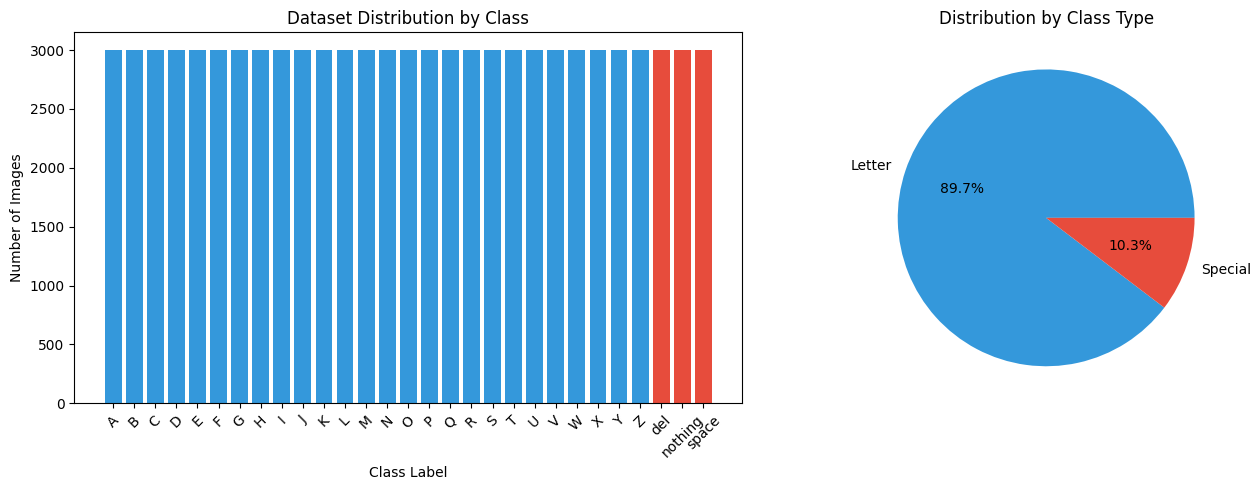

In [14]:
# Visualize dataset distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of samples per class
colors = ['#3498db' if t == 'Letter' else '#e74c3c' for t in stats_df['Type']]
axes[0].bar(stats_df['Label'], stats_df['Count'], color=colors)
axes[0].set_xlabel('Class Label')
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Dataset Distribution by Class')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart of class types
type_counts = stats_df.groupby('Type')['Count'].sum()
axes[1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', 
            colors=['#3498db', '#e74c3c', '#95a5a6'])
axes[1].set_title('Distribution by Class Type')

plt.tight_layout()
plt.savefig(MODEL_SAVE_DIR / 'dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

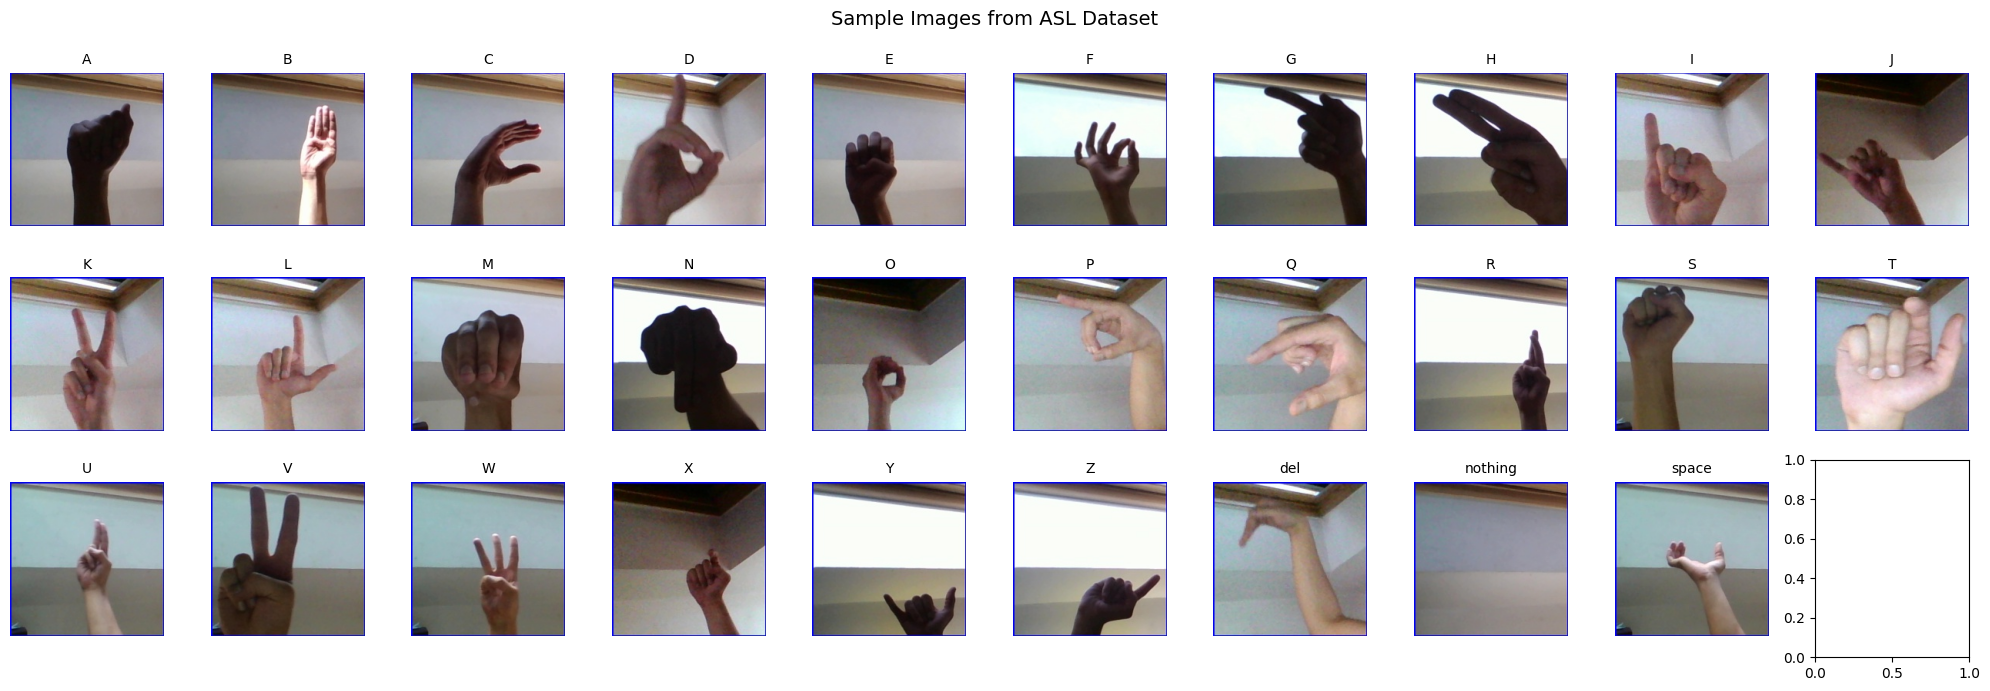

In [15]:
# Sample images visualization
fig, axes = plt.subplots(3, 10, figsize=(20, 7))
fig.suptitle('Sample Images from ASL Dataset', fontsize=14)

for idx, label in enumerate(LABELS[:30]):
    row, col = idx // 10, idx % 10
    label_dir = DATASET_DIR / label
    
    if label_dir.exists():
        images = list(label_dir.glob("*.jpg"))[:1]
        if images:
            img = cv2.imread(str(images[0]))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[row, col].imshow(img)
    
    axes[row, col].set_title(label, fontsize=10)
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(MODEL_SAVE_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Landmark Extraction

Extract hand landmarks using MediaPipe. Each hand has 21 landmarks with x, y coordinates (42 features total).

In [16]:
# Initialize MediaPipe Hands
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

hands = mp_hands.Hands(static_image_mode=True, min_detection_confidence=0.5, max_num_hands=1)
print("MediaPipe Hands initialized!")

MediaPipe Hands initialized!


I0000 00:00:1767371329.966068   54335 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Pro


In [17]:
# Check for cached data
data_file = MODEL_SAVE_DIR / 'landmark_data.pickle'

if data_file.exists():
    print("Loading cached data...")
    with open(data_file, 'rb') as f:
        cached = pickle.load(f)
    data = cached['data']
    labels_list = cached['labels']
    print(f"Loaded {len(data)} samples")
else:
    print("\n" + "=" * 60)
    print("EXTRACTING LANDMARKS")
    print("=" * 60)
    
    data = []
    labels_list = []
    extraction_stats = []
    
    for label in tqdm(LABELS, desc="Processing classes"):
        label_dir = DATASET_DIR / label
        
        if not label_dir.exists():
            extraction_stats.append({'Label': label, 'Total': 0, 'Extracted': 0})
            continue
        
        image_files = list(label_dir.glob("*.jpg")) + list(label_dir.glob("*.png"))
        np.random.shuffle(image_files)
        image_files = image_files[:SAMPLES_PER_CLASS]
        
        success_count = 0
        for img_path in image_files:
            try:
                img = cv2.imread(str(img_path))
                if img is None:
                    continue
                    
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                results = hands.process(img_rgb)
                
                if results.multi_hand_landmarks:
                    data_aux = []
                    for hand_landmarks in results.multi_hand_landmarks:
                        for lm in hand_landmarks.landmark:
                            data_aux.append(lm.x)
                            data_aux.append(lm.y)
                    
                    if len(data_aux) == 42:  # Ensure correct number of features
                        data.append(data_aux)
                        labels_list.append(label)
                        success_count += 1
            except Exception as e:
                continue
        
        extraction_stats.append({'Label': label, 'Total': len(image_files), 'Extracted': success_count})
    
    # Save data
    with open(data_file, 'wb') as f:
        pickle.dump({'data': data, 'labels': labels_list}, f)
    
    # Show extraction stats
    stats_df = pd.DataFrame(extraction_stats)
    stats_df['Rate'] = (stats_df['Extracted'] / stats_df['Total'] * 100).fillna(0).round(1)
    print(f"\nExtraction Statistics:")
    print(stats_df.to_string(index=False))
    print(f"\nTotal samples: {len(data)}")
    print(f"Average extraction rate: {stats_df['Rate'].mean():.1f}%")

Loading cached data...
Loaded 6411 samples


W0000 00:00:1767371329.976399   58472 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1767371329.981705   58472 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [18]:
# Convert to numpy arrays
X = np.array(data)
y = np.array(labels_list)

print("\n" + "=" * 60)
print("DATA SUMMARY")
print("=" * 60)
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Unique classes: {len(np.unique(y))}")

# Class distribution
unique, counts = np.unique(y, return_counts=True)
class_dist = pd.DataFrame({'Label': unique, 'Samples': counts})
print(f"\nSamples per class:")
print(class_dist.to_string(index=False))


DATA SUMMARY
Features shape: (6411, 42)
Labels shape: (6411,)
Unique classes: 29

Samples per class:
  Label  Samples
      A      224
      B      220
      C      202
      D      240
      E      240
      F      289
      G      258
      H      245
      I      233
      J      249
      K      275
      L      255
      M      161
      N      131
      O      228
      P      199
      Q      208
      R      269
      S      261
      T      233
      U      247
      V      261
      W      248
      X      218
      Y      258
      Z      227
    del      167
nothing        1
  space      164


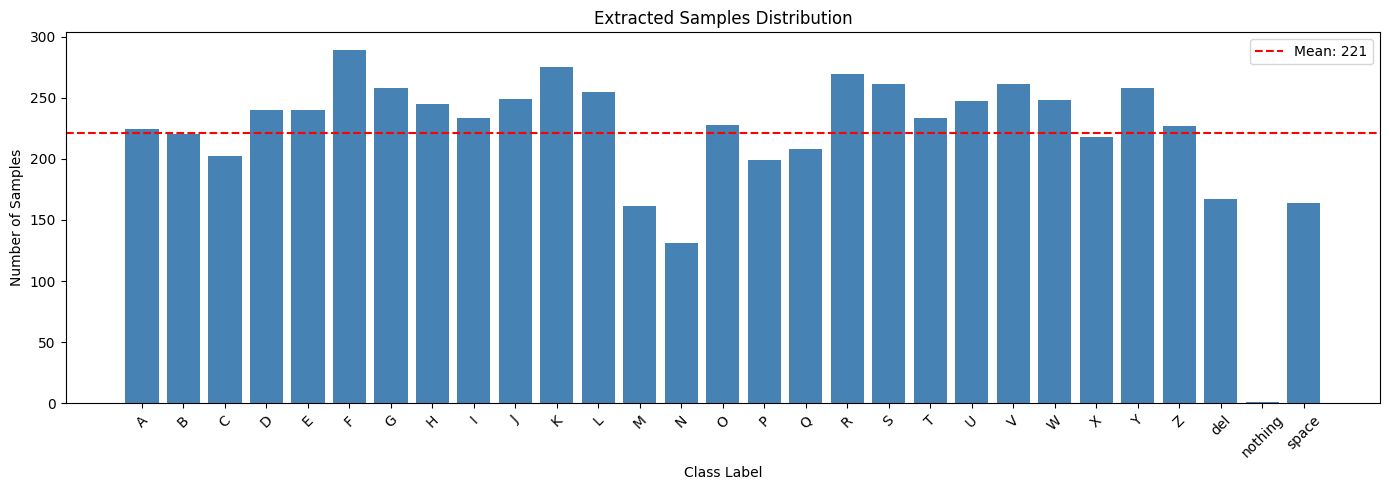

In [19]:
# Visualize extracted samples distribution
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(class_dist['Label'], class_dist['Samples'], color='steelblue')
ax.set_xlabel('Class Label')
ax.set_ylabel('Number of Samples')
ax.set_title('Extracted Samples Distribution')
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=class_dist['Samples'].mean(), color='red', linestyle='--', label=f'Mean: {class_dist["Samples"].mean():.0f}')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_SAVE_DIR / 'extracted_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Model Training & Comparison

We'll compare multiple sklearn classifiers:
1. **Random Forest** - Ensemble of decision trees
2. **Gradient Boosting** - Sequential ensemble method
3. **SVM** - Support Vector Machine
4. **KNN** - K-Nearest Neighbors
5. **MLP** - Multi-layer Perceptron (Neural Network)

In [20]:
# Filter out classes with too few samples (need at least 2 for stratified split)
from collections import Counter

# Count samples per class
class_counts = Counter(y)
print("Samples per class:")
for label, count in sorted(class_counts.items()):
    print(f"  {label}: {count}")

# Remove classes with less than 5 samples
min_samples = 5
valid_indices = [i for i, label in enumerate(y) if class_counts[label] >= min_samples]
X_filtered = X[valid_indices]
y_filtered = y[valid_indices]

print(f"\nFiltered: {len(X)} -> {len(X_filtered)} samples")
print(f"Removed classes with < {min_samples} samples")

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_filtered)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_encoded, test_size=TEST_SIZE, random_state=42, stratify=y_encoded
)

# Scale features for SVM and MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"Classes: {len(label_encoder.classes_)}")

Samples per class:
  A: 224
  B: 220
  C: 202
  D: 240
  E: 240
  F: 289
  G: 258
  H: 245
  I: 233
  J: 249
  K: 275
  L: 255
  M: 161
  N: 131
  O: 228
  P: 199
  Q: 208
  R: 269
  S: 261
  T: 233
  U: 247
  V: 261
  W: 248
  X: 218
  Y: 258
  Z: 227
  del: 167
  nothing: 1
  space: 164

Filtered: 6411 -> 6410 samples
Removed classes with < 5 samples

Training set: 5128 samples
Test set: 1282 samples
Classes: 28


In [21]:
# Define models to compare
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'MLP': MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=42, verbose=True)
}

print(f"Models to compare: {list(models.keys())}")

Models to compare: ['Random Forest', 'Gradient Boosting', 'SVM', 'KNN', 'MLP']


In [22]:
# Train and evaluate all models
print("\n" + "=" * 60)
print("TRAINING MODELS")
print("=" * 60)

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Use scaled data for SVM and MLP
    if name in ['SVM', 'MLP']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'predictions': y_pred
    }
    
    print(f"  {name}: Accuracy = {accuracy:.2%}")

print("\n" + "=" * 60)
print("TRAINING COMPLETE!")
print("=" * 60)


TRAINING MODELS

Training Random Forest...
  Random Forest: Accuracy = 93.76%

Training Gradient Boosting...
  Gradient Boosting: Accuracy = 91.26%

Training SVM...
  SVM: Accuracy = 92.59%

Training KNN...
  KNN: Accuracy = 85.96%

Training MLP...
Iteration 1, loss = 2.82570606
Iteration 2, loss = 1.54875046
Iteration 3, loss = 0.80565378
Iteration 4, loss = 0.51317634
Iteration 5, loss = 0.38519133
Iteration 6, loss = 0.31288349
Iteration 7, loss = 0.26469188
Iteration 8, loss = 0.22887922
Iteration 9, loss = 0.20371784
Iteration 10, loss = 0.17758319
Iteration 11, loss = 0.16160554
Iteration 12, loss = 0.14729957
Iteration 13, loss = 0.13150951
Iteration 14, loss = 0.12391390
Iteration 15, loss = 0.11411479
Iteration 16, loss = 0.10335211
Iteration 17, loss = 0.09423919
Iteration 18, loss = 0.08760091
Iteration 19, loss = 0.07932881
Iteration 20, loss = 0.07551896
Iteration 21, loss = 0.06729555
Iteration 22, loss = 0.06352471
Iteration 23, loss = 0.06106697
Iteration 24, loss = 0.

In [23]:
# Model comparison summary
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

comparison_df = pd.DataFrame([
    {'Model': name, 'Accuracy': f"{r['accuracy']:.2%}"}
    for name, r in results.items()
]).sort_values('Accuracy', ascending=False)

print(comparison_df.to_string(index=False))

# Find best model
best_model_name = max(results.keys(), key=lambda x: results[x]['accuracy'])
best_accuracy = results[best_model_name]['accuracy']
print(f"\nBest Model: {best_model_name}")
print(f"Best Accuracy: {best_accuracy:.2%}")


MODEL COMPARISON
            Model Accuracy
              MLP   97.89%
    Random Forest   93.76%
              SVM   92.59%
Gradient Boosting   91.26%
              KNN   85.96%

Best Model: MLP
Best Accuracy: 97.89%


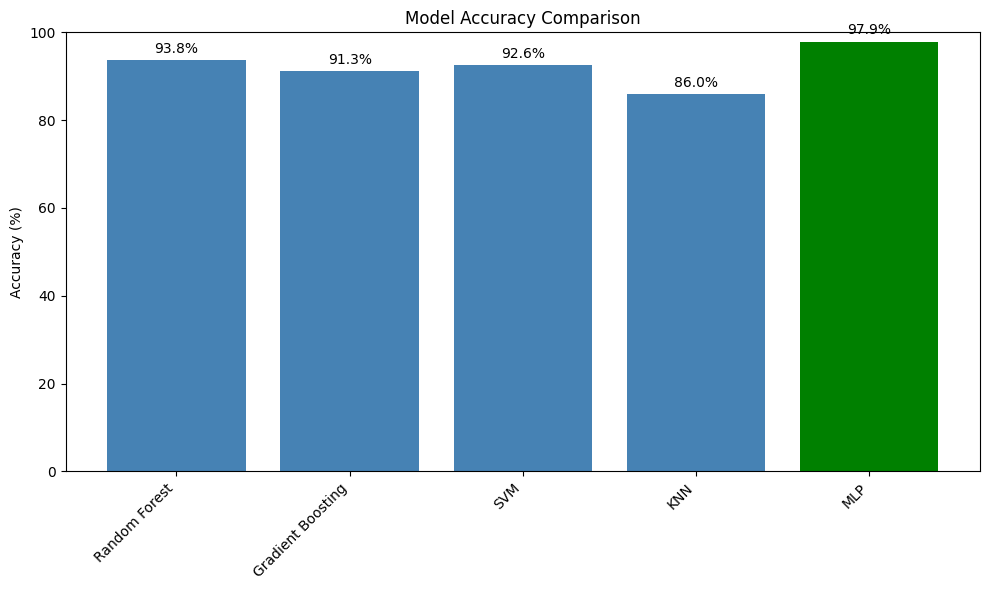

In [24]:
# Visualize model comparison
fig, ax = plt.subplots(figsize=(10, 6))

model_names = list(results.keys())
accuracies = [results[n]['accuracy'] * 100 for n in model_names]
colors = ['green' if n == best_model_name else 'steelblue' for n in model_names]

bars = ax.bar(model_names, accuracies, color=colors)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Accuracy Comparison')
ax.set_ylim([0, 100])

# Add value labels
for bar, acc in zip(bars, accuracies):
    ax.annotate(f'{acc:.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(MODEL_SAVE_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Detailed Evaluation of Best Model

In [25]:
# Get best model predictions
best_model = results[best_model_name]['model']
y_pred = results[best_model_name]['predictions']

# Classification Report
print("\n" + "=" * 60)
print(f"CLASSIFICATION REPORT - {best_model_name}")
print("=" * 60)

# Get class names
class_names = label_encoder.classes_

print(classification_report(y_test, y_pred, target_names=class_names, digits=3))


CLASSIFICATION REPORT - MLP
              precision    recall  f1-score   support

           A      1.000     0.956     0.977        45
           B      1.000     1.000     1.000        44
           C      0.952     1.000     0.976        40
           D      1.000     1.000     1.000        48
           E      1.000     1.000     1.000        48
           F      1.000     1.000     1.000        58
           G      1.000     1.000     1.000        52
           H      1.000     0.939     0.968        49
           I      1.000     0.935     0.966        46
           J      0.980     1.000     0.990        50
           K      0.982     1.000     0.991        55
           L      1.000     0.980     0.990        51
           M      0.938     0.938     0.938        32
           N      0.923     0.923     0.923        26
           O      0.957     0.978     0.968        46
           P      0.973     0.900     0.935        40
           Q      0.894     1.000     0.944        4

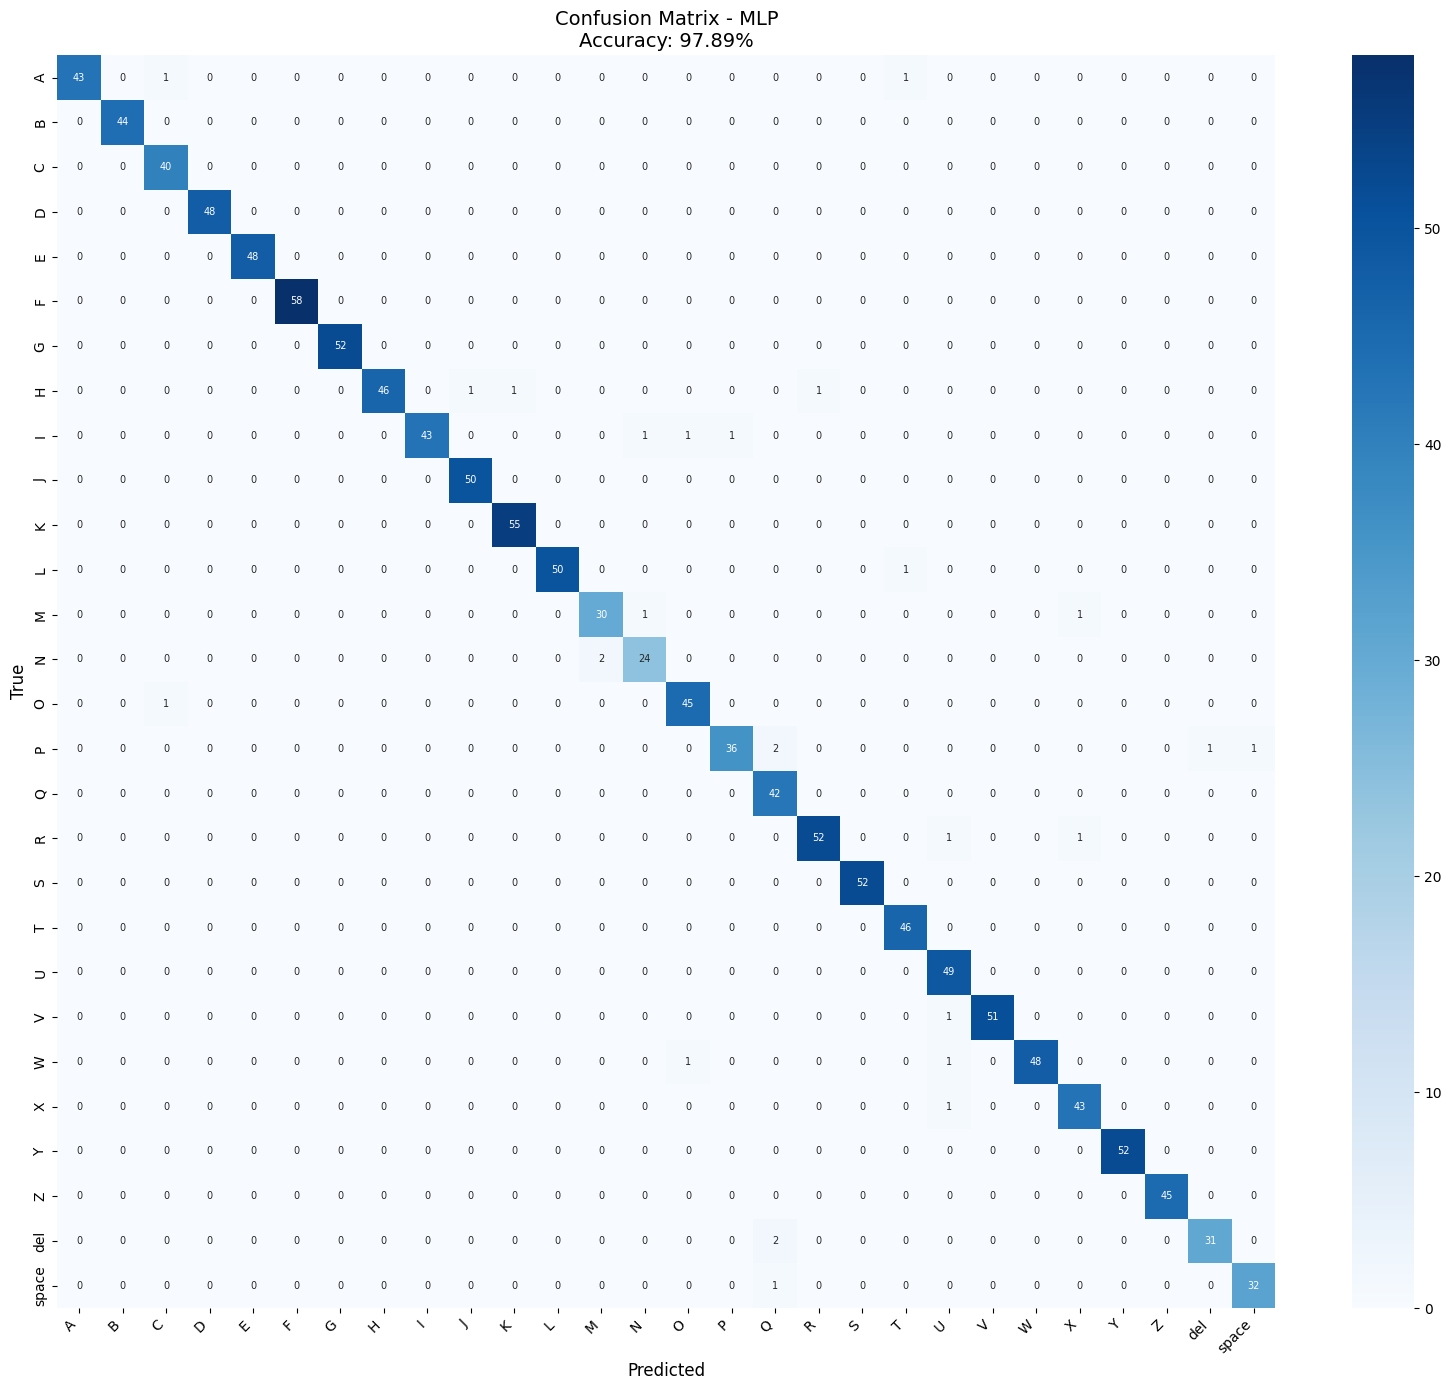

In [26]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 7})
plt.title(f'Confusion Matrix - {best_model_name}\nAccuracy: {best_accuracy:.2%}', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(MODEL_SAVE_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

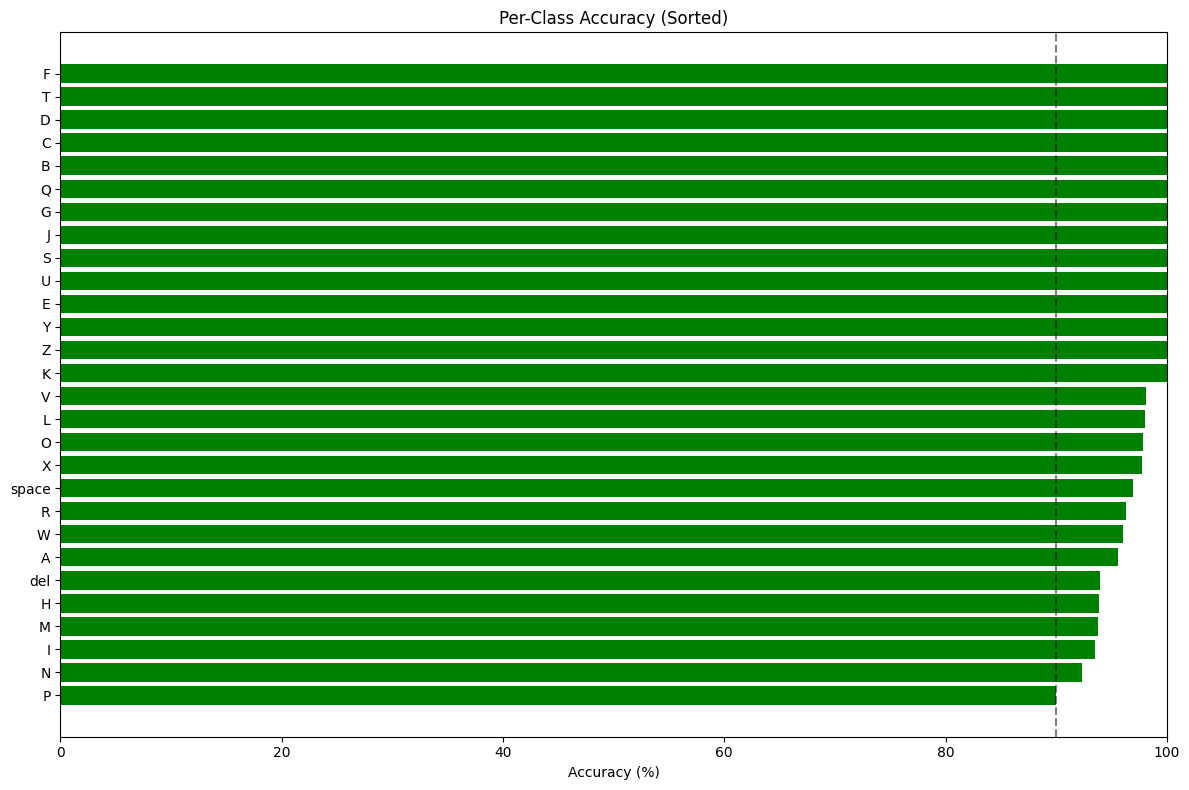


Lowest Accuracy Classes:
Label  Accuracy  Samples
    P  0.900000       40
    N  0.923077       26
    I  0.934783       46
    M  0.937500       32
    H  0.938776       49

Highest Accuracy Classes:
Label  Accuracy  Samples
    B       1.0       44
    C       1.0       40
    D       1.0       48
    T       1.0       46
    F       1.0       58


In [27]:
# Per-class accuracy
class_accuracy = []
for i, class_name in enumerate(class_names):
    mask = y_test == i
    if mask.sum() > 0:
        acc = (y_pred[mask] == i).mean()
        class_accuracy.append({'Label': class_name, 'Accuracy': acc, 'Samples': mask.sum()})

class_acc_df = pd.DataFrame(class_accuracy).sort_values('Accuracy', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['red' if acc < 0.8 else 'orange' if acc < 0.9 else 'green' for acc in class_acc_df['Accuracy']]
ax.barh(class_acc_df['Label'], class_acc_df['Accuracy'] * 100, color=colors)
ax.axvline(x=90, color='black', linestyle='--', alpha=0.5, label='90% threshold')
ax.set_xlabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy (Sorted)')
ax.set_xlim([0, 100])
plt.tight_layout()
plt.savefig(MODEL_SAVE_DIR / 'per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# Show worst/best classes
print("\nLowest Accuracy Classes:")
print(class_acc_df.head(5).to_string(index=False))
print("\nHighest Accuracy Classes:")
print(class_acc_df.tail(5).to_string(index=False))

## 6. Save Best Model

In [28]:
# Save best model
model_path = MODEL_SAVE_DIR / 'asl_model.pickle'

with open(model_path, 'wb') as f:
    pickle.dump({
        'model': best_model,
        'label_encoder': label_encoder,
        'scaler': scaler if best_model_name in ['SVM', 'MLP'] else None,
        'model_name': best_model_name,
        'accuracy': best_accuracy,
        'class_names': list(class_names),
        'feature_dim': FEATURE_DIM
    }, f)

print("\n" + "=" * 60)
print("MODEL SAVED")
print("=" * 60)
print(f"\nModel: {model_path}")
print(f"Size: {os.path.getsize(model_path) / 1024:.1f} KB")


MODEL SAVED

Model: ../models/asl_model.pickle
Size: 1495.0 KB


In [29]:
# Final Report
print("\n" + "=" * 70)
print("                    ASL MODEL - FINAL REPORT")
print("=" * 70)

print(f"""
PROJECT: ASL Finger Spelling Recognition
DATE: {datetime.now().strftime('%Y-%m-%d %H:%M')}

DATASET SUMMARY:
  - Source: Kaggle ASL Alphabet Dataset
  - Total Classes: {NUM_CLASSES}
  - Samples Extracted: {len(X):,}
  - Feature Dimension: {FEATURE_DIM} (21 landmarks x 2)

DATA SPLIT:
  - Training: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)
  - Test: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)

MODELS COMPARED:
""")

for name, r in sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True):
    marker = "*" if name == best_model_name else " "
    print(f"  {marker} {name}: {r['accuracy']:.2%}")

print(f"""
BEST MODEL: {best_model_name}
  - Test Accuracy: {best_accuracy:.2%}

MODEL FILE: {model_path}

USAGE:
  Run: streamlit run app.py
""")

print("=" * 70)
print("                         TRAINING COMPLETE")
print("=" * 70)


                    ASL MODEL - FINAL REPORT

PROJECT: ASL Finger Spelling Recognition
DATE: 2026-01-02 17:30

DATASET SUMMARY:
  - Source: Kaggle ASL Alphabet Dataset
  - Total Classes: 29
  - Samples Extracted: 6,411
  - Feature Dimension: 42 (21 landmarks x 2)

DATA SPLIT:
  - Training: 5,128 (80.0%)
  - Test: 1,282 (20.0%)

MODELS COMPARED:

  * MLP: 97.89%
    Random Forest: 93.76%
    SVM: 92.59%
    Gradient Boosting: 91.26%
    KNN: 85.96%

BEST MODEL: MLP
  - Test Accuracy: 97.89%

MODEL FILE: ../models/asl_model.pickle

USAGE:
  Run: streamlit run app.py

                         TRAINING COMPLETE
